# 🤖 IPL High Score Prediction (50+ Runs) - Modeling

In this notebook we will:

- Load ML-ready dataset
- Build preprocessing pipeline
- Train multiple classification models
- Evaluate using F1-score, ROC-AUC, Confusion Matrix
- Tune best model
- Save final model


## 🧠 CODE CELL — Imports

In [40]:
import numpy as np
import pandas as pd


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib


## 🧠 Loading Data

In [41]:
df = pd.read_csv("../data/final_ml.csv")
df.head()


,season,match_id,match_name,home_team,away_team,venue,city,country,current_innings,innings_id,...,fullname,ballsfaced,minutes,captain,isnotout,runningscore,runningover,shorttext,commentary,high_score
0,2023,1359475,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",Ahmedabad,India,CSK,1,...,Devon Conway,6.0,0,False,False,0,2.2,b Mohammed Shami,<strong>Shami breaches the defences of Conway<...,0
1,2023,1359475,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",Ahmedabad,India,CSK,1,...,Ruturaj Gaikwad,50.0,0,False,False,0,17.1,c Shubman Gill b Joseph,"Joseph misses the yorker, but is still a hard-...",1
2,2023,1359475,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",Ahmedabad,India,CSK,1,...,Moeen Ali,17.0,0,False,False,0,5.5,c &dagger;Saha b Rashid Khan,"<strong>Rashid strikes back, Moeen has nicked ...",0
3,2023,1359475,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",Ahmedabad,India,CSK,1,...,Ben Stokes,6.0,0,False,False,0,7.4,c &dagger;Saha b Rashid Khan,<strong>Rashid takes out both Moeen and Stokes...,0
4,2023,1359475,GT v CSK,GT,CSK,"Narendra Modi Stadium, Motera, Ahmedabad",Ahmedabad,India,CSK,1,...,Ambati Rayudu,12.0,0,False,False,0,12.5,b Little,Maiden IPL wicket for Josh Little. Rayudu dash...,0


## 🎯 Splitting X and y

In [42]:
features = [
    "ballsfaced",
    "minutes",
    "runningscore",
    "runningover",
    "isnotout",
    "captain",
    "current_innings",
    "innings_id"
]

X = df[features]
y = df["high_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


## 🏗️ Building Pipeline

In [43]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])


## 🤖 Models

In [44]:
models = {
    "Logistic": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42)
}


## 📊 Training & Evaluation

In [45]:
results = []

for name, model in models.items():
    pipe = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]
    
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append([name, f1, auc])
    
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))



Logistic
              precision    recall  f1-score   support

           0       0.99      0.91      0.95      2814
           1       0.56      0.95      0.71       330

    accuracy                           0.92      3144
   macro avg       0.78      0.93      0.83      3144
weighted avg       0.95      0.92      0.93      3144


RandomForest
              precision    recall  f1-score   support

           0       0.97      0.98      0.97      2814
           1       0.80      0.74      0.77       330

    accuracy                           0.95      3144
   macro avg       0.88      0.86      0.87      3144
weighted avg       0.95      0.95      0.95      3144


GradientBoosting
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2814
           1       0.83      0.76      0.79       330

    accuracy                           0.96      3144
   macro avg       0.90      0.87      0.89      3144
weighted avg       0.96      0.9

## 📊 Results Table

In [46]:
results_df = pd.DataFrame(results, columns=["Model", "F1", "ROC_AUC"])
results_df


,Model,F1,ROC_AUC
0,Logistic,0.705085,0.983596
1,RandomForest,0.766562,0.976546
2,GradientBoosting,0.793701,0.983331


In [47]:
pipe_lr = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(pipe_lr, param_grid, scoring="f1", cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_


## 📊 Final Evaluation

In [48]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


              precision    recall  f1-score   support

           0       0.99      0.91      0.95      2814
           1       0.56      0.94      0.70       330

    accuracy                           0.92      3144
   macro avg       0.78      0.93      0.83      3144
weighted avg       0.95      0.92      0.92      3144

ROC-AUC: 0.9836294716891731


## 🧱 Confusion Matrix

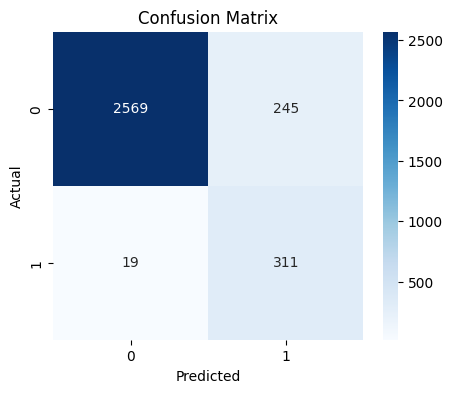

In [49]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


Text(0.5, 1.0, 'Top 20 Feature Importances from Logistic Regression')

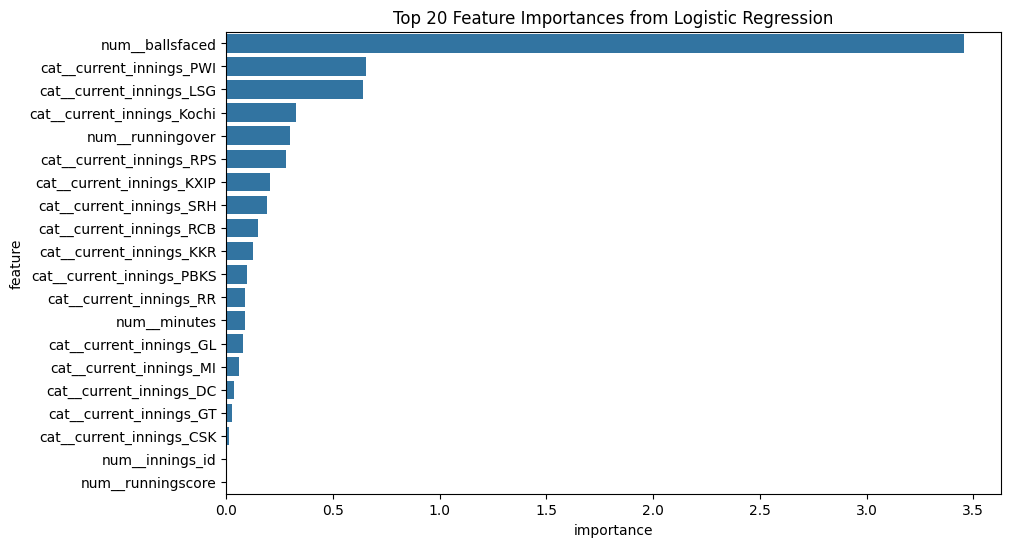

In [50]:
# Get feature names after preprocessing
feature_names = best_model.named_steps["prep"].get_feature_names_out()

# Get coefficients from Logistic Regression
coefficients = best_model.named_steps["model"].coef_[0]

# Create DataFrame
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": np.abs(coefficients)
}).sort_values(by="importance", ascending=False)

feat_imp.head(20)
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp.head(20), x="importance", y="feature")
plt.title("Top 20 Feature Importances from Logistic Regression")


In [51]:
joblib.dump(best_model, "../models/best_model.pkl")
print("Model saved to models/best_model.pkl")


Model saved to models/best_model.pkl
